In [28]:
!pip install pandas --quiet

In [29]:
import pandas as pd
medical_df = pd.read_csv('medical.csv')
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [30]:
medical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [31]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [32]:
!pip install plotly matplotlib seaborn --quiet
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [33]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [34]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [35]:
fig = px.histogram(medical_df, 
                   x='age', 
                   marginal='box', 
                   nbins=47, 
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

In [36]:
fig = px.histogram(medical_df, 
                   x='bmi', 
                   marginal='box', 
                   color_discrete_sequence=['red'], 
                   title='Distribution of BMI (Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

In [37]:
fig = px.histogram(medical_df, 
                   x='charges', 
                   marginal='box', 
                   color='smoker', 
                   color_discrete_sequence=['green', 'grey'], 
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

In [38]:
fig = px.histogram(medical_df, 
                   x='region', 
                   marginal='box', 
                   color='sex', 
                   color_discrete_sequence=['pink', 'blue'], 
                   title='Distribution of Region')
fig.update_layout(bargap=0.1)
fig.show()

In [39]:
medical_df.value_counts('smoker')

smoker
no     1064
yes     274
Name: count, dtype: int64

In [40]:
fig = px.histogram(medical_df,
                   x='smoker',
                   color='sex',
                   title='Smoker Distribution by Gender',
                   color_discrete_sequence=['pink', 'blue'])
fig.update_layout(bargap=0.1)
fig.show()

In [41]:
fig = px.histogram(
    medical_df,
    x='region',
    y='children',
    color='sex',
    histfunc='avg',
    title='Average Number of Children by Region and Sex'
)

fig.update_layout(bargap=0.1)
fig.show()

In [44]:
fig = px.scatter(medical_df,
                 x = 'age', 
                 y = 'charges',
                 color = 'smoker',
                 opacity = 0.8,
                 title = 'Age vs. Charges by Smoking Status',
                 color_discrete_sequence = ['green', 'grey'])
fig.update_traces(marker_size=5)
fig.show()

In [45]:
fig = px.scatter(
    medical_df,
    x='bmi',
    y='charges',
    color='smoker',
    title='Medical Charges vs BMI',
    color_discrete_sequence=['green', 'grey'],
    hover_data=['age', 'sex', 'region', 'children']
)
fig.update_traces(marker_size=5)
fig.show()

In [48]:
fig = px.violin(
    medical_df,
    x='children',
    y='charges',
    title='Distribution of Charges by Number of Children',
)
fig.update_layout(bargap=0.1)
fig.show()

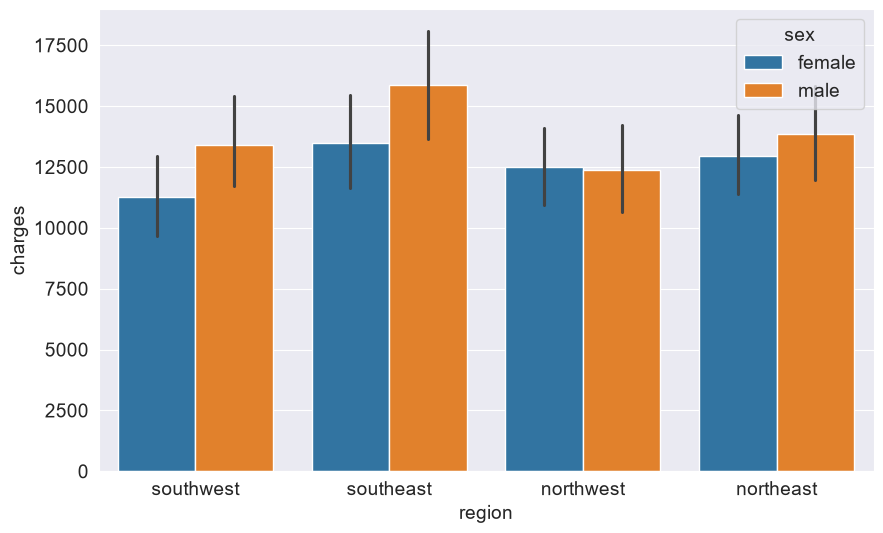

In [59]:
fig = sns.barplot(medical_df, x='region', y='charges', hue='sex')


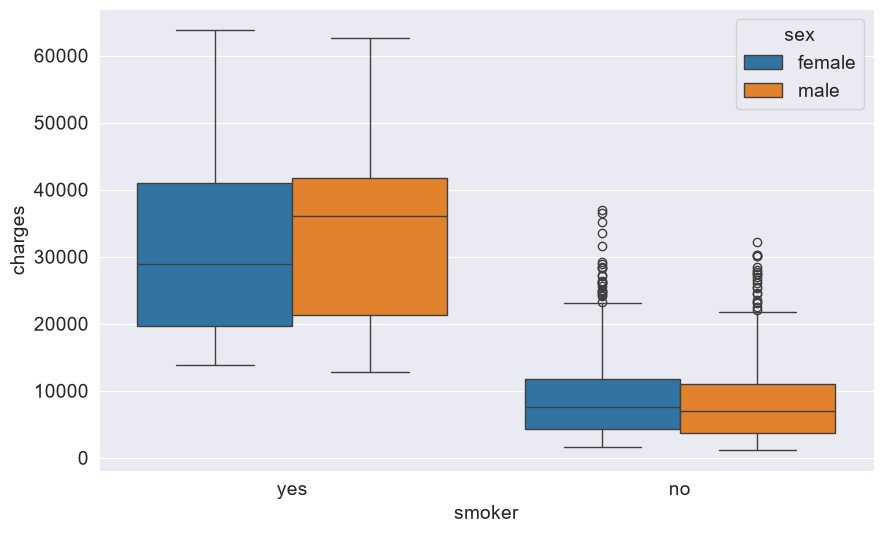

In [60]:
fig = sns.boxplot(medical_df, x='smoker', y='charges', hue='sex')

In [61]:
medical_df.charges.corr(medical_df.age)

np.float64(0.2990081933306478)

In [62]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362887)

In [63]:
medical_df.charges.corr(medical_df.children)

np.float64(0.06799822684790487)

In [64]:
smoker_numeric = medical_df.smoker.map({'yes': 1, 'no': 0})
medical_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984778)

In [66]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


Text(0.5, 1.0, 'Correlation Heatmap of Medical Dataset')

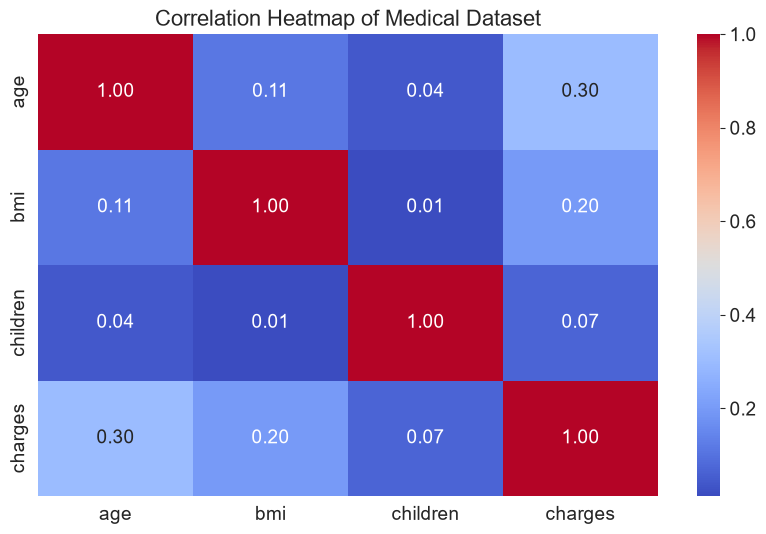

In [68]:
sns.heatmap(medical_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Medical Dataset', fontsize=16)